# Carbon-Aware Demand Coach API Analizi

Bu notebook, **GB Carbon Intensity API** verisini kullanarak saatlik karbon yoğunluğu profili oluşturur. Daha sonra REFIT cihaz kullanım olaylarıyla bu profili birleştirerek cihazların daha düşük karbonlu saatlerde çalıştırılması durumunda oluşabilecek tahmini CO₂ tasarrufunu hesaplar.

Akış sırası:
1. Gerekli kütüphaneler ve dosya yolları tanımlanır.
2. Carbon Intensity API'den veri çekilir ve saatlik profil oluşturulur.
3. REFIT cihaz kullanım verisi okunur.
4. Mevcut kullanım saati ile önerilen kullanım saati karşılaştırılır.
5. Sonuçlar CSV olarak kaydedilir ve grafiklerle görselleştirilir.
6. İsteğe bağlı olarak küçük bir `ipywidgets` arayüzü ile tekil cihaz önerisi hesaplanır.


In [1]:
# Temel veri işleme ve görselleştirme kütüphaneleri
from pathlib import Path

import requests
import pandas as pd
import matplotlib.pyplot as plt

# Notebook çıktılarının daha okunabilir görünmesi için pandas ayarları
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 1. Ayarlar ve Dosya Yolları

Bu bölümde analizde kullanılacak tarih aralığı ve dosya adları tek bir yerde tutulur. Böylece ileride tarih aralığı veya dosya adı değiştirileceğinde notebook içinde birçok hücreyi ayrı ayrı düzenlemeye gerek kalmaz.


In [2]:
# Carbon Intensity API için kullanılacak tarih aralığı
# API İngiltere/GB karbon yoğunluğu verisini yarım saatlik aralıklarla döndürür.
FROM_DATETIME = "2024-03-01T00:00Z"
TO_DATETIME = "2024-03-08T00:00Z"

# Girdi dosyası: REFIT cihaz kullanım olayları
EVENTS_CSV = Path("refit_appliance_events_final.csv")

# Çıktı dosyaları
CARBON_PROFILE_CSV = Path("gb_carbon_hour_profile.csv")
RECOMMENDATIONS_CSV = Path("carbon_aware_recommendations_gb_final.csv")
POSITIVE_RECOMMENDATIONS_CSV = Path("carbon_aware_positive_recommendations_gb_final.csv")
DEVICE_SUMMARY_CSV = Path("carbon_saving_summary_by_device.csv")

# Kullanıcı cihazı kaç saat erteleyebilir? Örneğin 8 saatlik pencere: mevcut saat + 8 saate kadar.
DEFAULT_FLEXIBILITY_HOURS = 8


## 2. Carbon Intensity API Verisini Çekme

Bu fonksiyon API'den gelen ham JSON verisini tabloya dönüştürür. Geçmiş tarihli veride `actual` değeri varsa onu kullanır; boşsa `forecast` değerine geri döner.


In [3]:
def fetch_carbon_intensity_data(from_datetime: str, to_datetime: str) -> pd.DataFrame:
    """GB Carbon Intensity API'den karbon yoğunluğu verisini çeker ve DataFrame'e dönüştürür."""
    url = f"https://api.carbonintensity.org.uk/intensity/{from_datetime}/{to_datetime}"

    response = requests.get(url, headers={"Accept": "application/json"}, timeout=30)
    response.raise_for_status()  # API hatası varsa burada anlaşılır bir hata verir.

    data = response.json()
    records = []

    # API her kayıt için başlangıç, bitiş ve karbon yoğunluğu bilgisi döndürür.
    for item in data.get("data", []):
        intensity = item.get("intensity", {})
        records.append({
            "from": item.get("from"),
            "to": item.get("to"),
            "forecast": intensity.get("forecast"),
            "actual": intensity.get("actual"),
            "index": intensity.get("index"),
        })

    carbon_raw = pd.DataFrame(records)

    if carbon_raw.empty:
        raise ValueError("API'den veri alınamadı. Tarih aralığını veya internet bağlantısını kontrol edin.")

    return carbon_raw


carbon_raw = fetch_carbon_intensity_data(FROM_DATETIME, TO_DATETIME)
carbon_raw.head()


,from,to,forecast,actual,index
0,2024-02-29T23:30Z,2024-03-01T00:00Z,172,155,moderate
1,2024-03-01T00:00Z,2024-03-01T00:30Z,174,157,moderate
2,2024-03-01T00:30Z,2024-03-01T01:00Z,150,161,moderate
3,2024-03-01T01:00Z,2024-03-01T01:30Z,152,157,moderate
4,2024-03-01T01:30Z,2024-03-01T02:00Z,154,155,moderate


## 3. Saatlik Karbon Profili Oluşturma

API verisi yarım saatlik aralıklarla geldiği için önce saat bilgisi çıkarılır. Daha sonra aynı saat içindeki değerlerin ortalaması alınarak 0–23 saatleri için ortalama karbon yoğunluğu profili oluşturulur.


In [4]:
def build_hourly_carbon_profile(carbon_raw: pd.DataFrame) -> pd.DataFrame:
    """Ham API verisinden 24 saatlik ortalama karbon yoğunluğu profili üretir."""
    carbon_df = carbon_raw.copy()

    # Tarih sütunlarını datetime formatına çeviriyoruz.
    carbon_df["from"] = pd.to_datetime(carbon_df["from"])
    carbon_df["to"] = pd.to_datetime(carbon_df["to"])

    # Saatlik analiz için tarih ve saat bilgisi çıkarılır.
    carbon_df["date"] = carbon_df["from"].dt.date
    carbon_df["hour"] = carbon_df["from"].dt.hour

    # Geçmiş veride actual daha uygundur. Boş değer varsa forecast kullanılır.
    carbon_df["carbon_intensity_g_per_kwh"] = carbon_df["actual"].fillna(carbon_df["forecast"])

    # Önce gün-saat bazında, sonra tüm günler üzerinden saat bazında ortalama alınır.
    carbon_hourly = (
        carbon_df
        .groupby(["date", "hour"], as_index=False)
        .agg(carbon_intensity_g_per_kwh=("carbon_intensity_g_per_kwh", "mean"))
    )

    carbon_profile = (
        carbon_hourly
        .groupby("hour", as_index=False)
        .agg(carbon_intensity_g_per_kwh=("carbon_intensity_g_per_kwh", "mean"))
        .sort_values("hour")
        .reset_index(drop=True)
    )

    return carbon_profile


carbon_profile = build_hourly_carbon_profile(carbon_raw)
carbon_profile.to_csv(CARBON_PROFILE_CSV, index=False)
carbon_profile.head()


,hour,carbon_intensity_g_per_kwh
0,0,168.000000
1,1,166.428571
2,2,163.857143
3,3,163.928571
4,4,171.000000


In [5]:
# En düşük karbon yoğunluğuna sahip ilk 10 saati listeler.
carbon_profile.sort_values("carbon_intensity_g_per_kwh").head(10)


,hour,carbon_intensity_g_per_kwh
23,23,152.062500
22,22,154.857143
12,12,155.642857
11,11,155.857143
13,13,158.071429
2,2,163.857143
3,3,163.928571
10,10,165.357143
1,1,166.428571
14,14,166.928571


## 4. Saatlik Karbon Yoğunluğu Grafiği

Bu grafik, gün içinde hangi saatlerde karbon yoğunluğunun daha düşük olduğunu gösterir. En düşük saat ayrıca işaretlenir.


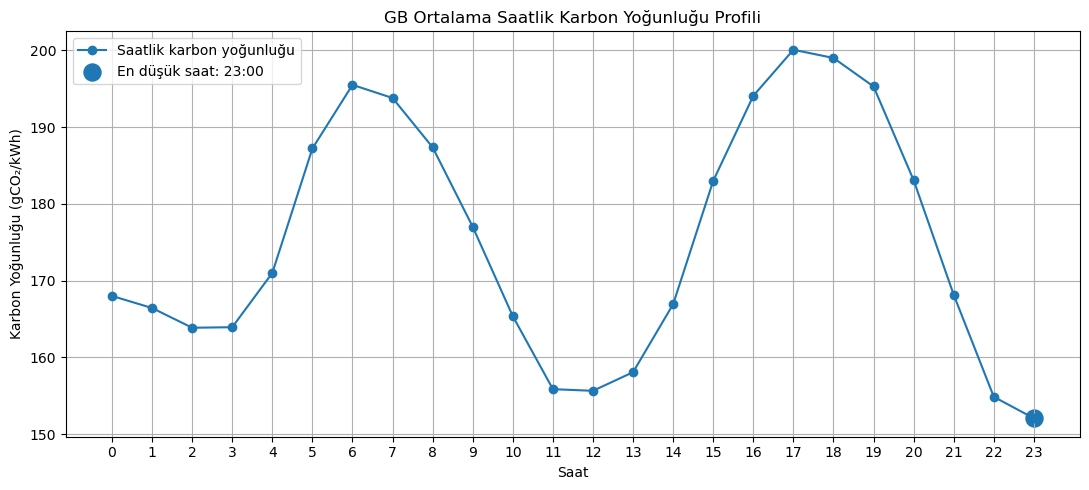

En düşük karbonlu saat: 23:00
Karbon yoğunluğu: 152.06 gCO₂/kWh


In [6]:
best_row = carbon_profile.loc[carbon_profile["carbon_intensity_g_per_kwh"].idxmin()]
best_hour = int(best_row["hour"])
best_carbon = float(best_row["carbon_intensity_g_per_kwh"])

plt.figure(figsize=(11, 5))
plt.plot(
    carbon_profile["hour"],
    carbon_profile["carbon_intensity_g_per_kwh"],
    marker="o",
    label="Saatlik karbon yoğunluğu"
)
plt.scatter(best_hour, best_carbon, s=150, label=f"En düşük saat: {best_hour}:00")

plt.title("GB Ortalama Saatlik Karbon Yoğunluğu Profili")
plt.xlabel("Saat")
plt.ylabel("Karbon Yoğunluğu (gCO₂/kWh)")
plt.xticks(range(24))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"En düşük karbonlu saat: {best_hour:02d}:00")
print(f"Karbon yoğunluğu: {best_carbon:.2f} gCO₂/kWh")


## 5. REFIT Cihaz Kullanım Verisini Okuma

Bu bölümde cihazların kullanım olayları okunur. Her olay için başlangıç saati çıkarılır. Daha sonra bu saat, karbon profiliyle eşleştirilir.


In [7]:
def load_refit_events(events_csv: Path) -> pd.DataFrame:
    """REFIT cihaz kullanım olaylarını okur ve zaman sütunlarını düzenler."""
    if not events_csv.exists():
        raise FileNotFoundError(
            f"{events_csv} bulunamadı. Dosyanın notebook ile aynı klasörde olduğundan emin olun."
        )

    events = pd.read_csv(events_csv)

    # Zaman sütunları datetime formatına çevrilir.
    events["start_time"] = pd.to_datetime(events["start_time"])
    events["end_time"] = pd.to_datetime(events["end_time"])

    # Karbon profili saatlik olduğu için olayın başlangıç saati kullanılır.
    events["start_hour"] = events["start_time"].dt.hour

    return events


events_df = load_refit_events(EVENTS_CSV)
print("Cihaz kullanım verisi boyutu:", events_df.shape)
events_df.head()


Cihaz kullanım verisi boyutu: (7240, 11)


,house,house_id,appliance_name,start_time,end_time,duration_min,energy_kwh,start_hour,start_date,max_power_watt,mean_power_watt
0,House1,1,tumble_dryer,2013-10-27 14:23:14,2013-10-27 14:47:18,24.066667,0.470819,14,2013-10-27,2647,1171.995885
1,House1,1,tumble_dryer,2013-12-26 12:06:34,2013-12-26 12:33:21,26.783333,0.610967,12,2013-12-26,1469,1358.815534
2,House1,1,tumble_dryer,2013-12-28 14:07:15,2013-12-28 14:27:33,20.300000,0.594763,14,2013-12-28,2571,1706.454023
3,House1,1,tumble_dryer,2014-07-11 05:03:09,2014-07-11 06:12:21,69.200000,0.535509,5,2014-07-11,520,448.396694
4,House1,1,tumble_dryer,2014-09-19 06:05:20,2014-09-19 06:26:10,20.833333,0.428015,6,2014-09-19,2625,1203.422535


## 6. Mevcut Kullanım Emisyonunu Hesaplama

Cihazın mevcut kullanım saatindeki karbon yoğunluğu ile cihazın enerji tüketimi çarpılarak tahmini CO₂ emisyonu hesaplanır.


In [8]:
def merge_events_with_carbon_profile(events: pd.DataFrame, profile: pd.DataFrame) -> pd.DataFrame:
    """Cihaz kullanım olaylarını başlangıç saatine göre karbon profiliyle birleştirir."""
    profile = profile.copy()
    profile["hour"] = profile["hour"].astype(int)
    profile["carbon_intensity_g_per_kwh"] = profile["carbon_intensity_g_per_kwh"].astype(float)

    merged = events.merge(
        profile,
        left_on="start_hour",
        right_on="hour",
        how="left"
    )

    # Emisyon hesabı: enerji tüketimi (kWh) x karbon yoğunluğu (gCO₂/kWh)
    merged["current_emission_g"] = (
        merged["energy_kwh"] * merged["carbon_intensity_g_per_kwh"]
    )

    return merged


merged_df = merge_events_with_carbon_profile(events_df, carbon_profile)
merged_df[[
    "appliance_name",
    "start_hour",
    "energy_kwh",
    "carbon_intensity_g_per_kwh",
    "current_emission_g"
]].head()


,appliance_name,start_hour,energy_kwh,carbon_intensity_g_per_kwh,current_emission_g
0,tumble_dryer,14,0.470819,166.928571,78.593078
1,tumble_dryer,12,0.610967,155.642857,95.092727
2,tumble_dryer,14,0.594763,166.928571,99.282994
3,tumble_dryer,5,0.535509,187.214286,100.254914
4,tumble_dryer,6,0.428015,195.500000,83.676878


## 7. En Uygun Kullanım Saatini Bulma

Kullanıcı cihazı belirli bir süre erteleyebiliyorsa, sistem sadece bu esneklik penceresi içindeki saatleri karşılaştırır. Örneğin mevcut saat 19:00 ve esneklik 8 saat ise 19:00–03:00 arası aday saatler değerlendirilir.


In [9]:
def find_best_hour_with_flexibility(
    current_hour: int,
    carbon_profile: pd.DataFrame,
    flexibility_hours: int = DEFAULT_FLEXIBILITY_HOURS
):
    """Mevcut saatten itibaren esneklik aralığı içinde en düşük karbonlu saati bulur."""
    current_hour = int(current_hour)
    flexibility_hours = int(flexibility_hours)

    # Saat 23'ten sonra tekrar 00'a dönmesi için modulo 24 kullanılır.
    candidate_hours = [(current_hour + i) % 24 for i in range(flexibility_hours + 1)]

    candidate_df = carbon_profile[carbon_profile["hour"].isin(candidate_hours)].copy()
    best_row = candidate_df.loc[candidate_df["carbon_intensity_g_per_kwh"].idxmin()]

    recommended_hour = int(best_row["hour"])
    recommended_carbon = float(best_row["carbon_intensity_g_per_kwh"])

    return recommended_hour, recommended_carbon, candidate_df


def calculate_recommendation(
    device_name: str,
    current_hour: int,
    energy_kwh: float,
    flexibility_hours: int = DEFAULT_FLEXIBILITY_HOURS,
    profile: pd.DataFrame = carbon_profile
) -> dict:
    """Tek bir cihaz için mevcut saat ve önerilen saat karşılaştırmasını hesaplar."""
    current_hour = int(current_hour)
    energy_kwh = float(energy_kwh)

    current_row = profile.loc[profile["hour"] == current_hour].iloc[0]
    current_carbon = float(current_row["carbon_intensity_g_per_kwh"])

    recommended_hour, recommended_carbon, candidate_df = find_best_hour_with_flexibility(
        current_hour=current_hour,
        carbon_profile=profile,
        flexibility_hours=flexibility_hours
    )

    current_emission = energy_kwh * current_carbon
    recommended_emission = energy_kwh * recommended_carbon
    co2_saving = current_emission - recommended_emission
    co2_saving_percent = (co2_saving / current_emission * 100) if current_emission > 0 else 0

    return {
        "device_name": device_name,
        "current_hour": current_hour,
        "recommended_hour": recommended_hour,
        "energy_kwh": energy_kwh,
        "current_carbon": current_carbon,
        "recommended_carbon": recommended_carbon,
        "current_emission": current_emission,
        "recommended_emission": recommended_emission,
        "co2_saving": co2_saving,
        "co2_saving_percent": co2_saving_percent,
        "candidate_df": candidate_df,
    }


## 8. Tüm REFIT Olayları İçin Öneri Hesaplama

Bu bölümde her cihaz kullanım olayı için önerilen saat, önerilen karbon yoğunluğu ve tahmini CO₂ kazancı hesaplanır.


In [10]:
def add_recommendations_to_events(
    merged: pd.DataFrame,
    profile: pd.DataFrame,
    flexibility_hours: int = DEFAULT_FLEXIBILITY_HOURS
) -> pd.DataFrame:
    """Tüm cihaz olayları için önerilen saati ve CO₂ tasarrufunu hesaplar."""
    result_df = merged.copy()

    recommended_hours = []
    recommended_carbons = []

    for start_hour in result_df["start_hour"]:
        rec_hour, rec_carbon, _ = find_best_hour_with_flexibility(
            current_hour=start_hour,
            carbon_profile=profile,
            flexibility_hours=flexibility_hours
        )
        recommended_hours.append(rec_hour)
        recommended_carbons.append(rec_carbon)

    result_df["recommended_hour"] = recommended_hours
    result_df["recommended_carbon_intensity_g_per_kwh"] = recommended_carbons

    result_df["recommended_emission_g"] = (
        result_df["energy_kwh"] * result_df["recommended_carbon_intensity_g_per_kwh"]
    )

    result_df["co2_saving_g"] = (
        result_df["current_emission_g"] - result_df["recommended_emission_g"]
    )

    result_df["co2_saving_percent"] = (
        result_df["co2_saving_g"] / result_df["current_emission_g"] * 100
    )

    return result_df


recommendations_df = add_recommendations_to_events(
    merged_df,
    carbon_profile,
    flexibility_hours=DEFAULT_FLEXIBILITY_HOURS
)

recommendations_df[[
    "appliance_name",
    "start_hour",
    "recommended_hour",
    "energy_kwh",
    "current_emission_g",
    "recommended_emission_g",
    "co2_saving_g",
    "co2_saving_percent"
]].head()


,appliance_name,start_hour,recommended_hour,energy_kwh,current_emission_g,recommended_emission_g,co2_saving_g,co2_saving_percent
0,tumble_dryer,14,22,0.470819,78.593078,72.909625,5.683453,7.231493
1,tumble_dryer,12,12,0.610967,95.092727,95.092727,0.000000,0.000000
2,tumble_dryer,14,22,0.594763,99.282994,92.103350,7.179643,7.231493
3,tumble_dryer,5,12,0.535509,100.254914,83.348133,16.906781,16.863792
4,tumble_dryer,6,12,0.428015,83.676878,66.617434,17.059444,20.387285


## 9. Tasarruf Sağlayan Olayları Özetleme

Sadece önerilen saate kaydırıldığında pozitif CO₂ kazancı oluşturan olaylar filtrelenir. Bu filtre, raporda gerçekten fayda sağlayan önerileri göstermek için kullanılır.


In [11]:
positive_df = recommendations_df[recommendations_df["co2_saving_g"] > 0].copy()

print("Tüm olay sayısı:", len(recommendations_df))
print("Tasarruf sağlayan olay sayısı:", len(positive_df))
print("Tasarruf sağlayan oran (%):", round(len(positive_df) / len(recommendations_df) * 100, 2))


Tüm olay sayısı: 7240
Tasarruf sağlayan olay sayısı: 6161
Tasarruf sağlayan oran (%): 85.1


In [12]:
summary_by_device = (
    positive_df
    .groupby("appliance_name")
    .agg(
        event_count=("appliance_name", "count"),
        avg_energy_kwh=("energy_kwh", "mean"),
        avg_current_emission_g=("current_emission_g", "mean"),
        avg_recommended_emission_g=("recommended_emission_g", "mean"),
        avg_saving_g=("co2_saving_g", "mean"),
        avg_saving_percent=("co2_saving_percent", "mean"),
    )
    .round(2)
    .sort_values("avg_saving_g", ascending=False)
)

summary_by_device


,event_count,avg_energy_kwh,avg_current_emission_g,avg_recommended_emission_g,avg_saving_g,avg_saving_percent
appliance_name,,,,,,
tumble_dryer,991,0.99,180.66,153.26,27.40,14.19
washing_machine,705,0.92,166.72,143.34,23.39,13.80
dishwasher,4181,0.64,116.75,97.99,18.77,15.37
washer_dryer,284,0.65,119.15,100.47,18.68,14.86


## 10. Sonuçları Kaydetme

Bu bölümde üç temel çıktı dosyası oluşturulur:
- Tüm öneriler
- Sadece pozitif tasarruf sağlayan öneriler
- Cihaz bazlı özet tablo


In [13]:
recommendations_df.to_csv(RECOMMENDATIONS_CSV, index=False)
positive_df.to_csv(POSITIVE_RECOMMENDATIONS_CSV, index=False)
summary_by_device.to_csv(DEVICE_SUMMARY_CSV)

print("Kaydedilen dosyalar:")
print("-", RECOMMENDATIONS_CSV)
print("-", POSITIVE_RECOMMENDATIONS_CSV)
print("-", DEVICE_SUMMARY_CSV)


Kaydedilen dosyalar:
- carbon_aware_recommendations_gb_final.csv
- carbon_aware_positive_recommendations_gb_final.csv
- carbon_saving_summary_by_device.csv


## 11. Sonuç Grafikleri

Aşağıdaki grafikler rapor ve sunum için en anlamlı özetleri verir:
1. Cihazlara göre ortalama CO₂ tasarrufu
2. Mevcut ve önerilen kullanım emisyonu karşılaştırması


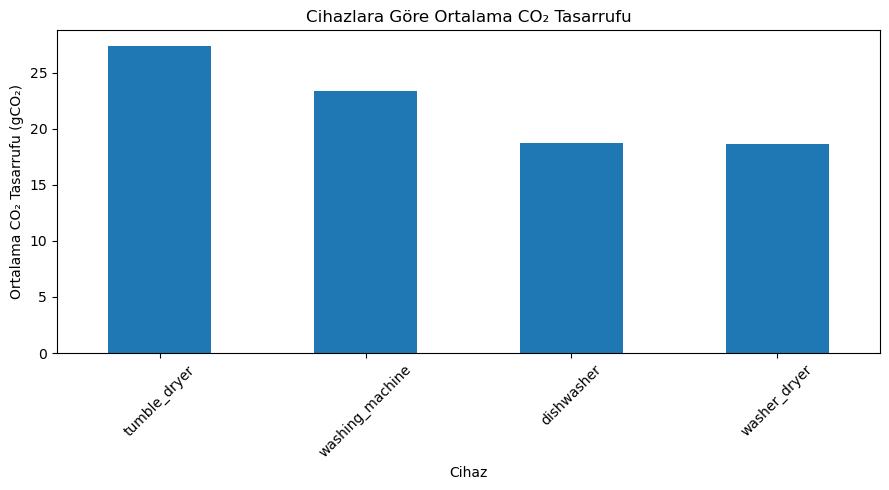

In [14]:
avg_saving = (
    positive_df
    .groupby("appliance_name")["co2_saving_g"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
avg_saving.plot(kind="bar")
plt.title("Cihazlara Göre Ortalama CO₂ Tasarrufu")
plt.xlabel("Cihaz")
plt.ylabel("Ortalama CO₂ Tasarrufu (gCO₂)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


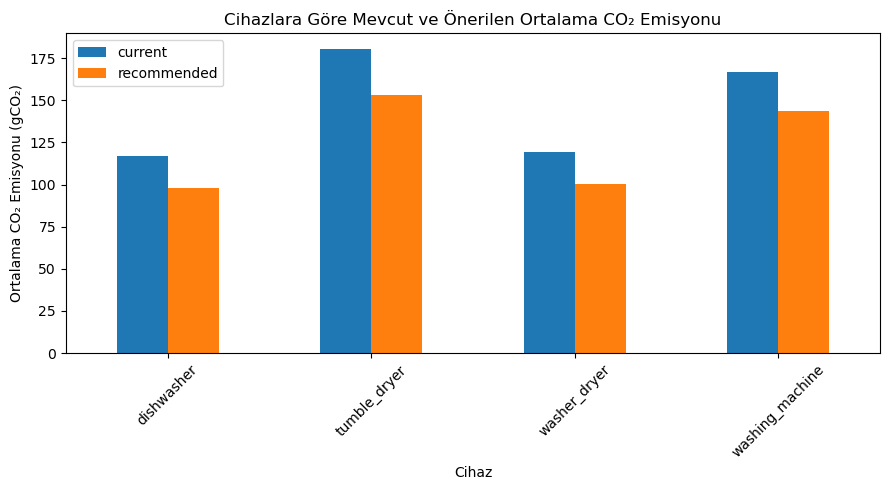

In [15]:
comparison = (
    positive_df
    .groupby("appliance_name")
    .agg(
        current=("current_emission_g", "mean"),
        recommended=("recommended_emission_g", "mean"),
    )
    .round(2)
)

comparison.plot(kind="bar", figsize=(9, 5))
plt.title("Cihazlara Göre Mevcut ve Önerilen Ortalama CO₂ Emisyonu")
plt.xlabel("Cihaz")
plt.ylabel("Ortalama CO₂ Emisyonu (gCO₂)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 12. Örnek Öneri Çıktısı

Bu hücre, tek bir cihaz olayı üzerinden sistemin kullanıcıya nasıl açıklama yapabileceğini gösterir.


In [16]:
if len(positive_df) > 0:
    sample = positive_df.sample(1, random_state=42).iloc[0]

    print(f"""
Cihaz: {sample['appliance_name']}
Mevcut kullanım saati: {int(sample['start_hour']):02d}:00
Önerilen kullanım saati: {int(sample['recommended_hour']):02d}:00

Enerji tüketimi: {sample['energy_kwh']:.3f} kWh

Mevcut karbon yoğunluğu: {sample['carbon_intensity_g_per_kwh']:.1f} gCO₂/kWh
Önerilen karbon yoğunluğu: {sample['recommended_carbon_intensity_g_per_kwh']:.1f} gCO₂/kWh

Mevcut emisyon: {sample['current_emission_g']:.1f} gCO₂
Önerilen emisyon: {sample['recommended_emission_g']:.1f} gCO₂

Tahmini CO₂ kazancı: {sample['co2_saving_g']:.1f} gCO₂
Azalma oranı: %{sample['co2_saving_percent']:.1f}
""")
else:
    print("Pozitif CO₂ tasarrufu sağlayan olay bulunamadı.")



Cihaz: dishwasher
Mevcut kullanım saati: 15:00
Önerilen kullanım saati: 23:00

Enerji tüketimi: 0.764 kWh

Mevcut karbon yoğunluğu: 183.0 gCO₂/kWh
Önerilen karbon yoğunluğu: 152.1 gCO₂/kWh

Mevcut emisyon: 139.9 gCO₂
Önerilen emisyon: 116.2 gCO₂

Tahmini CO₂ kazancı: 23.6 gCO₂
Azalma oranı: %16.9



## 13. Basit Kullanıcı Arayüzü

Bu bölüm, notebook içinde cihaz seçip öneri hesaplamak için küçük bir arayüz oluşturur. Google Colab kullanıyorsanız ve widget görünmezse önce `ipywidgets` kurulumunu/etkinleştirmesini yapmanız gerekebilir.


In [17]:
# Notebook içi etkileşimli arayüz için gerekli kütüphaneler
import ipywidgets as widgets
from IPython.display import display, clear_output

# Her cihaz için medyan enerji tüketimi alınır.
# Medyan kullanımı, uç değerlerden daha az etkilendiği için kullanıcı arayüzü açısından daha dengelidir.
device_energy_stats = (
    events_df
    .groupby("appliance_name")["energy_kwh"]
    .median()
    .round(3)
    .to_dict()
)

def update_energy_value(change):
    """Cihaz değiştiğinde enerji kutusunu seçilen cihazın medyan tüketimiyle günceller."""
    selected_device = change["new"]

    if not manual_energy_checkbox.value:
        energy_input.value = device_energy_stats.get(selected_device, 1.0)


In [18]:
# Arayüz bileşenleri
available_devices = sorted(events_df["appliance_name"].unique())
default_device = "washing_machine" if "washing_machine" in available_devices else available_devices[0]

device_dropdown = widgets.Dropdown(
    options=available_devices,
    value=default_device,
    description="Cihaz:",
    style={"description_width": "initial"}
)

hour_slider = widgets.IntSlider(
    value=19,
    min=0,
    max=23,
    step=1,
    description="Mevcut Saat:",
    style={"description_width": "initial"},
    continuous_update=False
)

flexibility_slider = widgets.IntSlider(
    value=DEFAULT_FLEXIBILITY_HOURS,
    min=1,
    max=24,
    step=1,
    description="Erteleme Esnekliği (saat):",
    style={"description_width": "initial"},
    continuous_update=False
)

manual_energy_checkbox = widgets.Checkbox(
    value=False,
    description="Enerji değerini manuel gireceğim"
)

energy_input = widgets.FloatText(
    value=device_energy_stats.get(default_device, 1.0),
    description="Enerji (kWh):",
    style={"description_width": "initial"}
)

calculate_button = widgets.Button(
    description="CO₂ Önerisi Hesapla",
    button_style="success"
)

output = widgets.Output()

device_dropdown.observe(update_energy_value, names="value")


In [19]:
def on_calculate_clicked(button):
    """Butona tıklandığında seçilen cihaz için karbon-duyarlı saat önerisi üretir."""
    with output:
        clear_output()

        device_name = device_dropdown.value
        current_hour = hour_slider.value
        flexibility_hours = flexibility_slider.value
        energy_kwh = energy_input.value

        result = calculate_recommendation(
            device_name=device_name,
            current_hour=current_hour,
            energy_kwh=energy_kwh,
            flexibility_hours=flexibility_hours,
            profile=carbon_profile
        )

        print("CARBON-AWARE DEMAND COACH")
        print("-" * 50)
        print(f"Cihaz: {result['device_name']}")
        print(f"Mevcut kullanım saati: {result['current_hour']:02d}:00")
        print(f"Erteleme esnekliği: {flexibility_hours} saat")
        print(f"Önerilen kullanım saati: {result['recommended_hour']:02d}:00")
        print(f"Enerji tüketimi: {result['energy_kwh']:.3f} kWh")
        print()
        print(f"Mevcut karbon yoğunluğu: {result['current_carbon']:.1f} gCO₂/kWh")
        print(f"Önerilen saat karbon yoğunluğu: {result['recommended_carbon']:.1f} gCO₂/kWh")
        print()
        print(f"Mevcut emisyon: {result['current_emission']:.1f} gCO₂")
        print(f"Önerilen emisyon: {result['recommended_emission']:.1f} gCO₂")
        print(f"Tahmini CO₂ kazancı: {result['co2_saving']:.1f} gCO₂")
        print(f"Azalma oranı: %{result['co2_saving_percent']:.1f}")
        print()

        if result["co2_saving"] > 0:
            print(
                f"Öneri: {result['device_name']} cihazını "
                f"{result['current_hour']:02d}:00 yerine "
                f"{result['recommended_hour']:02d}:00 saatinde çalıştırırsanız "
                f"yaklaşık %{result['co2_saving_percent']:.1f} daha az CO₂ salımı oluşur."
            )
        else:
            print("Bu cihaz seçilen saat aralığında zaten düşük karbonlu bir saate yakın çalıştırılıyor.")

        # Seçilen esneklik aralığını ve önerilen saati grafik üzerinde gösterir.
        plt.figure(figsize=(12, 5))
        plt.plot(
            carbon_profile["hour"],
            carbon_profile["carbon_intensity_g_per_kwh"],
            marker="o",
            label="Saatlik karbon yoğunluğu"
        )

        candidate_df = result["candidate_df"]
        plt.scatter(candidate_df["hour"], candidate_df["carbon_intensity_g_per_kwh"], s=80, label="Değerlendirilen saatler")
        plt.scatter(result["current_hour"], result["current_carbon"], s=180, label="Mevcut saat")
        plt.scatter(result["recommended_hour"], result["recommended_carbon"], s=180, label="Önerilen saat")

        plt.title("Esneklik Aralığında En Düşük Karbonlu Saat Önerisi")
        plt.xlabel("Saat")
        plt.ylabel("Karbon Yoğunluğu (gCO₂/kWh)")
        plt.xticks(range(24))
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


calculate_button.on_click(on_calculate_clicked)


In [20]:
ui = widgets.VBox([
    widgets.HTML("<h2>Carbon-Aware Demand Coach</h2>"),
    widgets.HTML("<p>REFIT cihaz tüketimi ve GB Carbon Intensity API verisi ile düşük karbonlu çalışma saati önerisi.</p>"),
    device_dropdown,
    hour_slider,
    flexibility_slider,
    manual_energy_checkbox,
    energy_input,
    calculate_button,
    output,
])

display(ui)
